In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from agentlab.analyze import inspect_results
from agentlab.experiments.loop import ExpResult

RESULTS_DIR = Path("/Users/montis/agentlab_results/2026-02-20_16-27-11_hpaagent-google-gemini-3-flash-preview-on-workarena-l1")

# Load Results

In [2]:
result_batches = []

for result_batch_dir in RESULTS_DIR.iterdir():
    if result_batch_dir != RESULTS_DIR / Path(".DS_Store"):
        result_batches.append(inspect_results.load_result_df(result_batch_dir))

Loading results:   0%|          | 0/1 [00:00<?, ?it/s]

Loading results: 100%|██████████| 1/1 [00:00<00:00, 2192.53it/s]
Searching experiments directories.: 0it [00:00, ?it/s]
Loading results: 100%|██████████| 1/1 [00:00<00:00, 2468.69it/s]
Searching experiments directories.: 0it [00:00, ?it/s]
Loading results: 100%|██████████| 1/1 [00:00<00:00, 1270.23it/s]
Searching experiments directories.: 0it [00:00, ?it/s]
Loading results: 100%|██████████| 1/1 [00:00<00:00, 2118.34it/s]
Searching experiments directories.: 0it [00:00, ?it/s]
Loading results: 100%|██████████| 1/1 [00:00<00:00, 922.64it/s]
Searching experiments directories.: 0it [00:00, ?it/s]
Loading results: 100%|██████████| 1/1 [00:00<00:00, 2824.45it/s]


In [3]:
result_df = pd.concat(result_batches)

In [4]:
for column in result_df.columns:
    print(column)

index
exp_dir
agent.chat_model.model_name
agent.chat_model.max_total_tokens
agent.chat_model.max_input_tokens
agent.chat_model.max_new_tokens
agent.chat_model.temperature
agent.chat_model.vision_support
agent.chat_model.log_probs
agent.flags.obs.use_html
agent.flags.obs.use_ax_tree
agent.flags.obs.use_tabs
agent.flags.obs.use_focused_element
agent.flags.obs.use_error_logs
agent.flags.obs.use_history
agent.flags.obs.use_past_error_logs
agent.flags.obs.use_action_history
agent.flags.obs.use_think_history
agent.flags.obs.use_diff
agent.flags.obs.html_type
agent.flags.obs.use_screenshot
agent.flags.obs.use_som
agent.flags.obs.extract_visible_tag
agent.flags.obs.extract_clickable_tag
agent.flags.obs.extract_coords
agent.flags.obs.filter_visible_elements_only
agent.flags.obs.openai_vision_detail
agent.flags.obs.filter_with_bid_only
agent.flags.obs.filter_som_only
agent.flags.action.action_set.subsets
agent.flags.action.action_set.multiaction
agent.flags.action.action_set.strict
agent.flags.a

In [5]:
# Just for checking

# all_task_names =result_df.index.get_level_values("env.task_name").values
# unique_task_names, unique_task_names_counts = np.unique(all_task_names, return_counts=True)
# print(len(unique_task_names))
# task_names_dict = dict(zip(unique_task_names, unique_task_names_counts))

# for k, v in task_names_dict.items():
#     print(f"{k}: {int(v)}")

In [6]:
failed_task_names =result_df[result_df["cum_reward"]==0].index.get_level_values("env.task_name").values
unique_failed_tasks, failed_task_counts = np.unique(failed_task_names, return_counts=True)
failed_tasks_dict = dict(zip(unique_failed_tasks, failed_task_counts))

for k, v in failed_tasks_dict.items():
    print(f"{k}: {int(v)}")

workarena.servicenow.create-change-request: 1
workarena.servicenow.create-hardware-asset: 9
workarena.servicenow.create-incident: 1
workarena.servicenow.filter-asset-list: 7
workarena.servicenow.filter-change-request-list: 7
workarena.servicenow.filter-hardware-list: 9
workarena.servicenow.filter-incident-list: 8
workarena.servicenow.filter-service-catalog-item-list: 9
workarena.servicenow.filter-user-list: 5
workarena.servicenow.knowledge-base-search: 4
workarena.servicenow.multi-chart-min-max-retrieval: 2
workarena.servicenow.multi-chart-value-retrieval: 4
workarena.servicenow.order-apple-watch: 1
workarena.servicenow.order-sales-laptop: 1
workarena.servicenow.single-chart-min-max-retrieval: 1
workarena.servicenow.single-chart-value-retrieval: 5
workarena.servicenow.sort-asset-list: 6
workarena.servicenow.sort-change-request-list: 6
workarena.servicenow.sort-hardware-list: 7
workarena.servicenow.sort-incident-list: 2
workarena.servicenow.sort-service-catalog-item-list: 5
workarena.se

In [9]:
# result_df[result_df.index.get_level_values(0).isin(['workarena.servicenow.multi-chart-value-retrieval'])][["env.task_seed", "cum_reward", "exp_dir"]]

In [8]:
report = inspect_results.global_report(result_df)
inspect_results.display_report(report)

Found multiple configuration, averaging across tasks and returning a per-agent report.


,agent.agent name,env.benchmark,avg reward,std err,avg steps,n completed,n err,cum cost
0,HPAAgent-google_gemini-3-flash-preview,workarena,0.684,0.026,8.863,329/330,3,74.1588


In [17]:
n_long_tasks = len(result_df[result_df["n_steps"]==15])
n_wrong_long_tasks = len(result_df[(result_df["n_steps"]==15) & (result_df["cum_reward"]==0)])
print(f"Tasks that reached 15 steps: {n_long_tasks}")
print(f"Wrong tasks that reached 15 steps: {n_wrong_long_tasks}")

Tasks that reached 15 steps: 79
Wrong tasks that reached 15 steps: 69


# Print Error Report

In [8]:
inspect_results.error_report(result_df, max_stack_trace=2, use_log=True)

''

# Load an Episode

In [ ]:
interesting_fields = ["workarena.servicenow.filter-incident-list", "workarena.servicenow.impersonation"]

In [10]:
filtered_result_df = result_df[result_df.index.get_level_values(level=0) == interesting_fields[1]]

Thinking: To impersonate a user in ServiceNow, I typically need to go to the User menu (the profile icon) and select "Impersonate user". Currently, I am logged in as Michael Alexander. I will click on the user profile button to reveal the menu options.
Action: click('179')


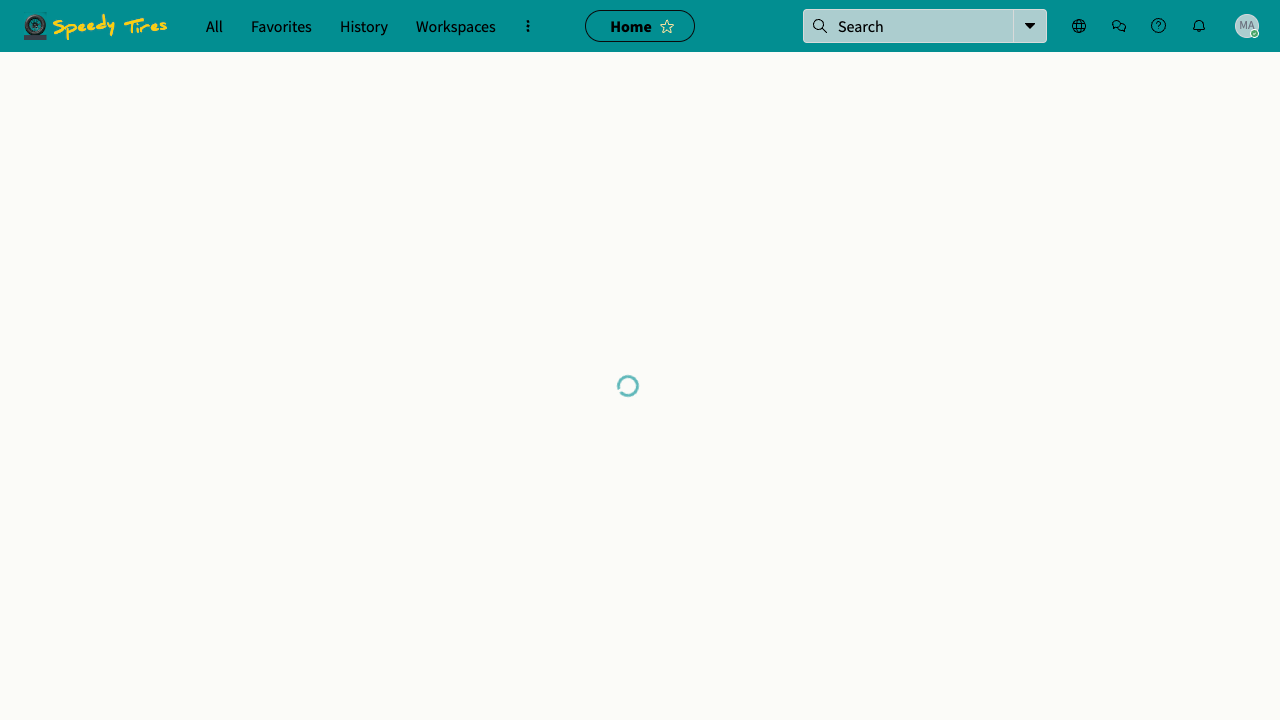

----------
Thinking: The user menu is already open from the previous action. I can see the "Impersonate user" option in the AXTree with bid '274'. I will click it to open the impersonation dialog.
Action: click('274')


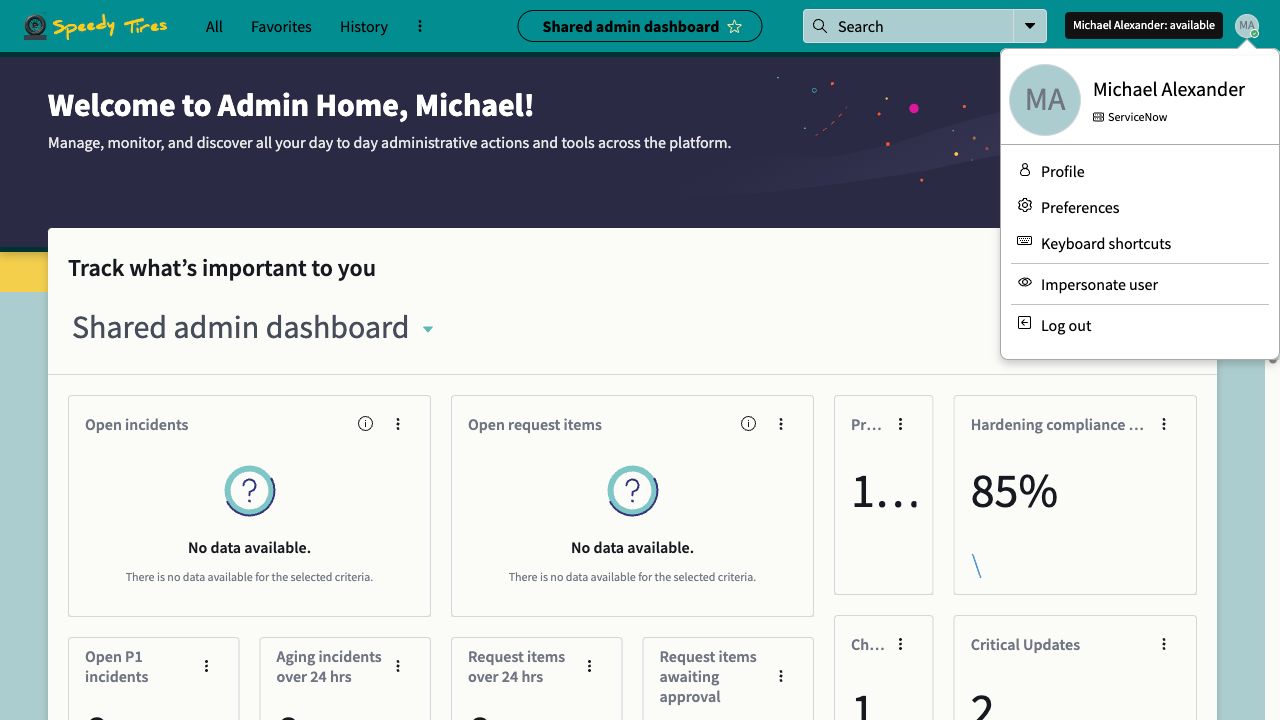

----------
Thinking: The previous attempt to click "Impersonate user" (bid '274') failed because the element was not visible in the AXTree of the current step. I need to click the user profile button (bid '179') again to ensure the menu is open and visible.
Action: click('179')


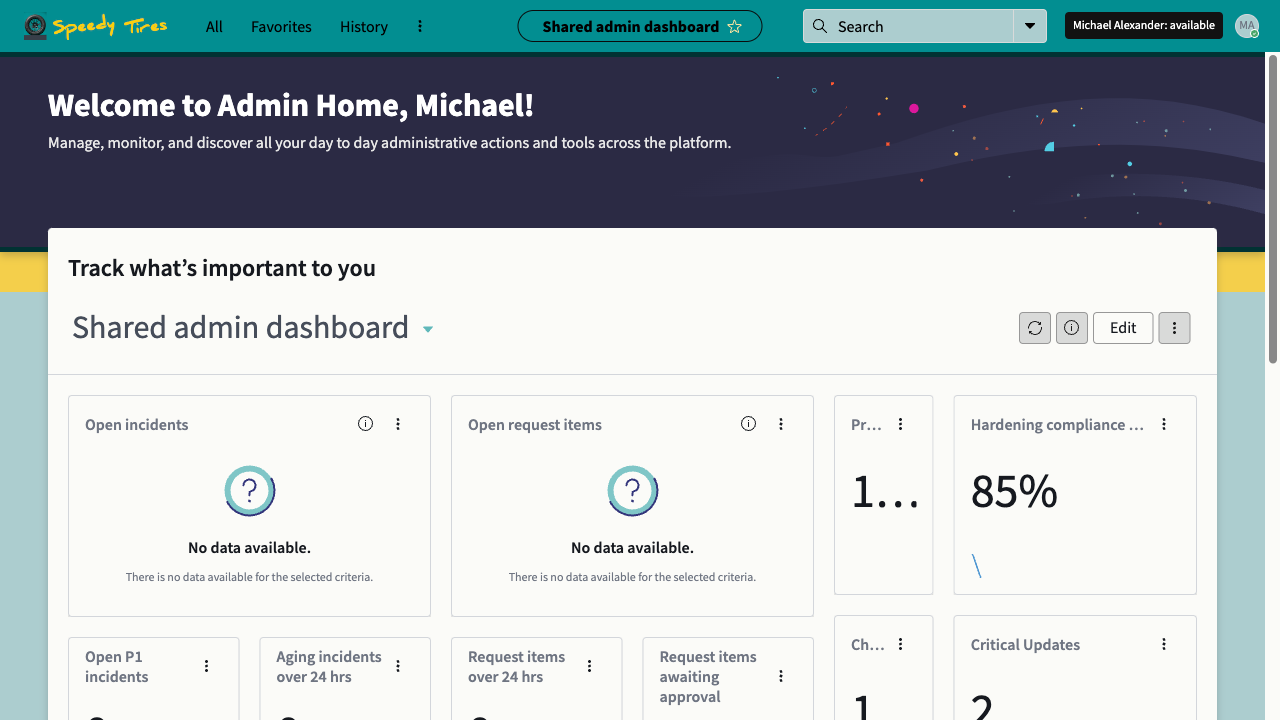

----------
Thinking: The user menu is already open and the "Impersonate user" menu item (bid '274') is visible in the AXTree. I will click it to proceed with the impersonation.
Action: click('274')


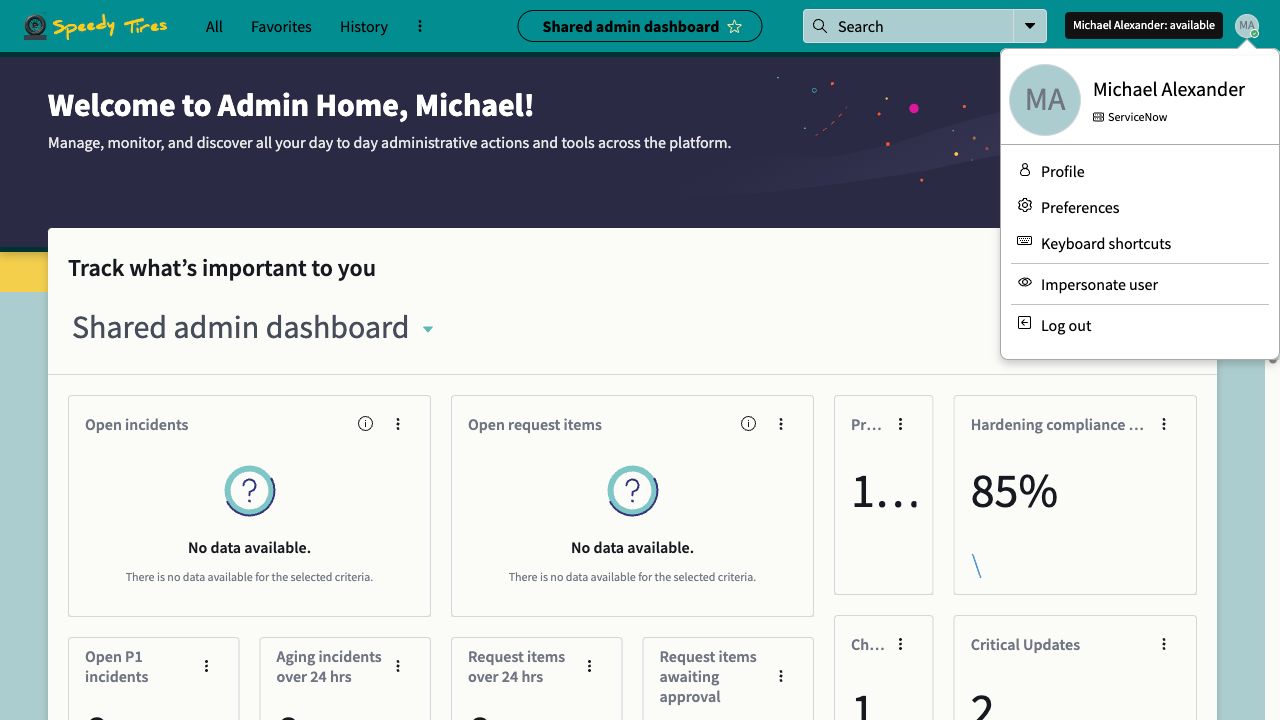

----------
Thinking: The previous action to click "Impersonate user" (bid '274') failed again. Looking at the current AXTree, the user menu (bid '179') is focused but the menu items (like 274) are NOT visible in the AXTree. This suggests the menu might not have opened or the AXTree hasn't updated to show the children. I will try clicking the user profile button (bid '179') again to ensure the menu is triggered.
Action: click('179')


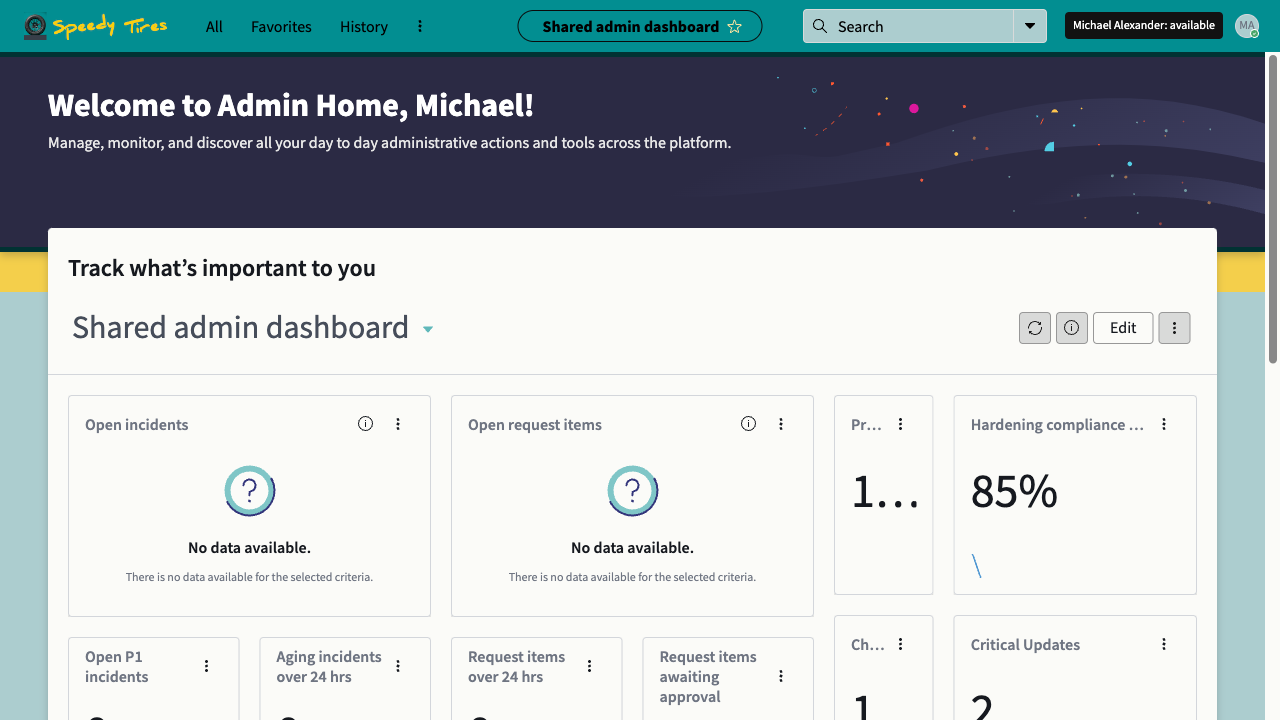

----------
Thinking: The user menu is open as indicated by the AXTree showing menu items like "Profile", "Preferences", and "Impersonate user" (bid '274'). I will click "Impersonate user" to open the search dialog for selecting the user Kay Ganguli.
Action: click('274')


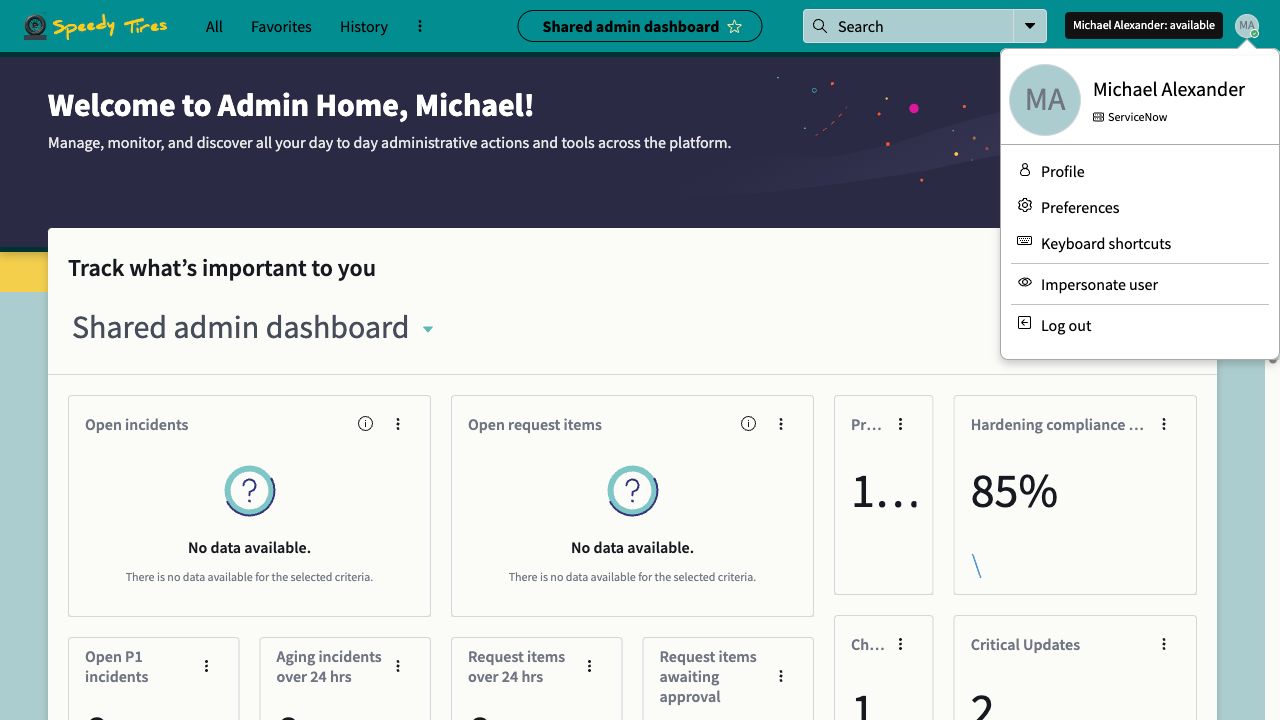

----------
Thinking: The previous attempt to click "Impersonate user" (bid '274') failed again with a visibility error. This is a common issue in ServiceNow's UI where the menu might be rendered in a way that the automation tool struggles to interact with it immediately. Since I've tried clicking the profile button and then the menu item multiple times, I will try to click the profile button (bid '179') one more time to ensure the menu is definitely active and then I will try to use the `press` action or a different approach if it fails again. However, looking at the AXTree, the profile button is currently focused. I'll try clicking it again.
Action: click('179')


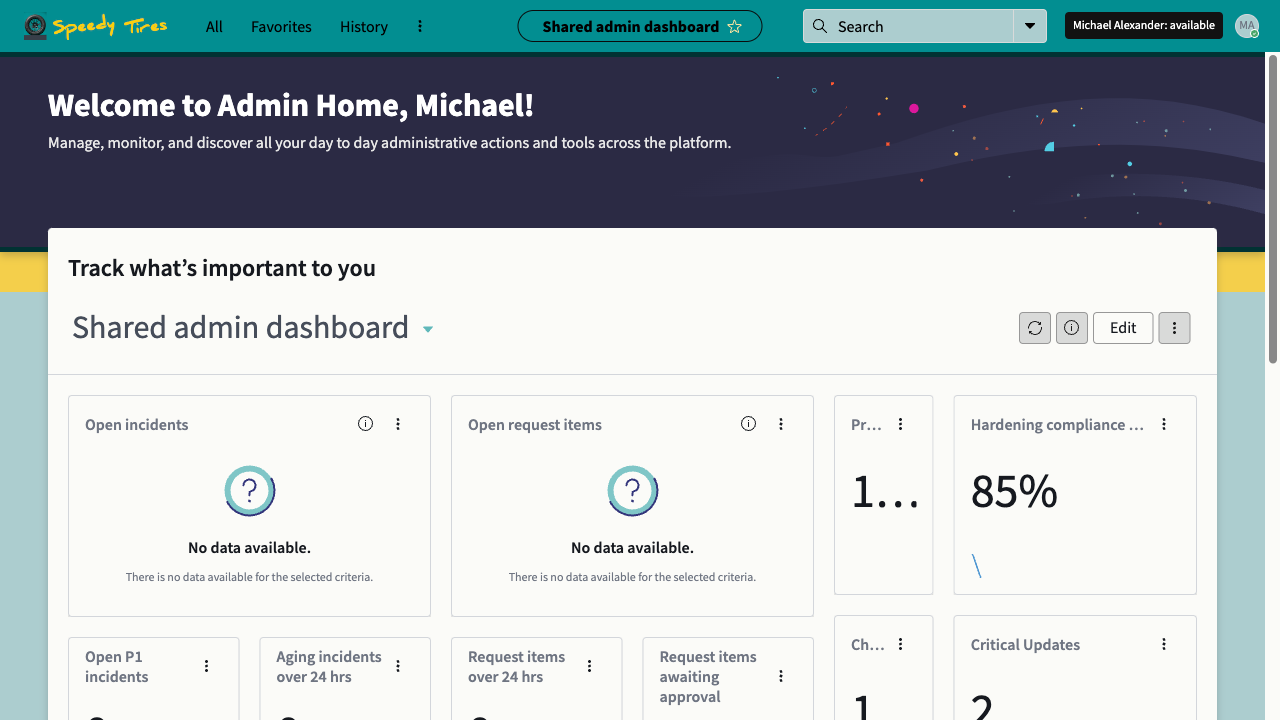

----------
Thinking: The user menu is currently open and visible in the AXTree. I will click on the "Impersonate user" menu item (bid '274') to open the impersonation search dialog.
Action: click('274')


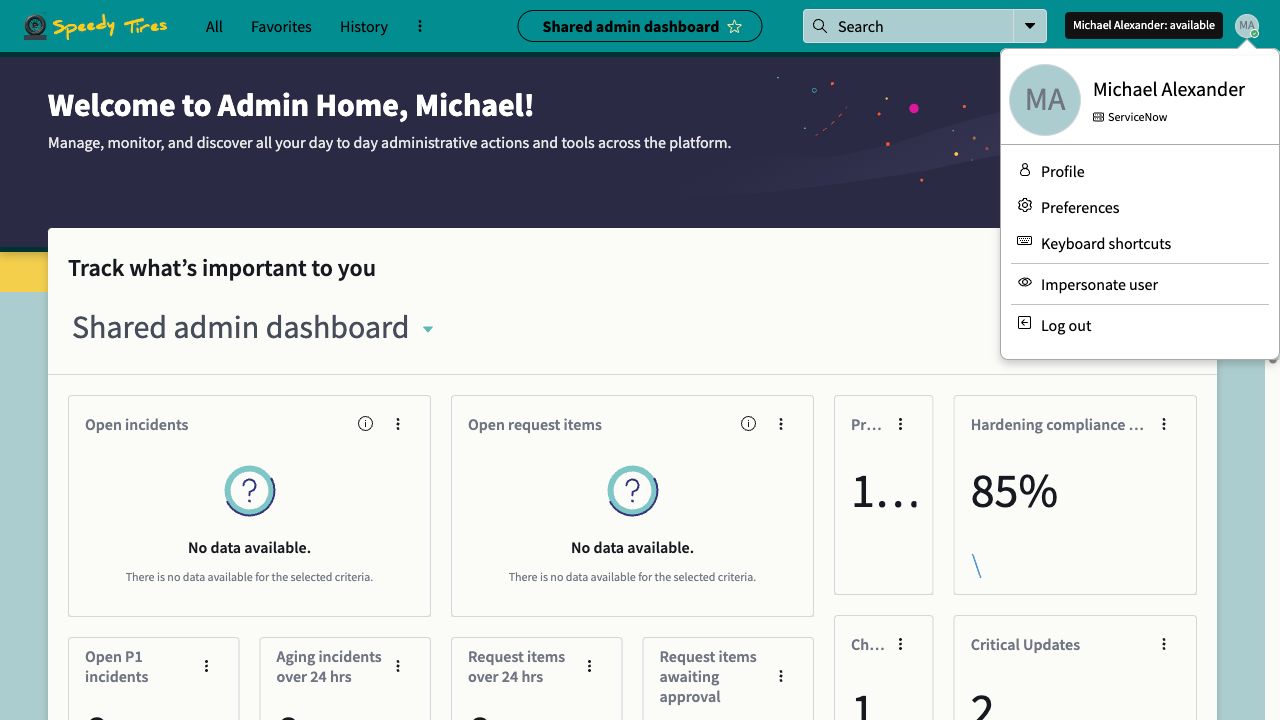

----------
Thinking: The previous action to click "Impersonate user" failed again. I will try to click the profile button '179' again. If the menu is already open, clicking it might close and reopen it, or I might need to wait. I'll try to click it one more time.
Action: click('179')


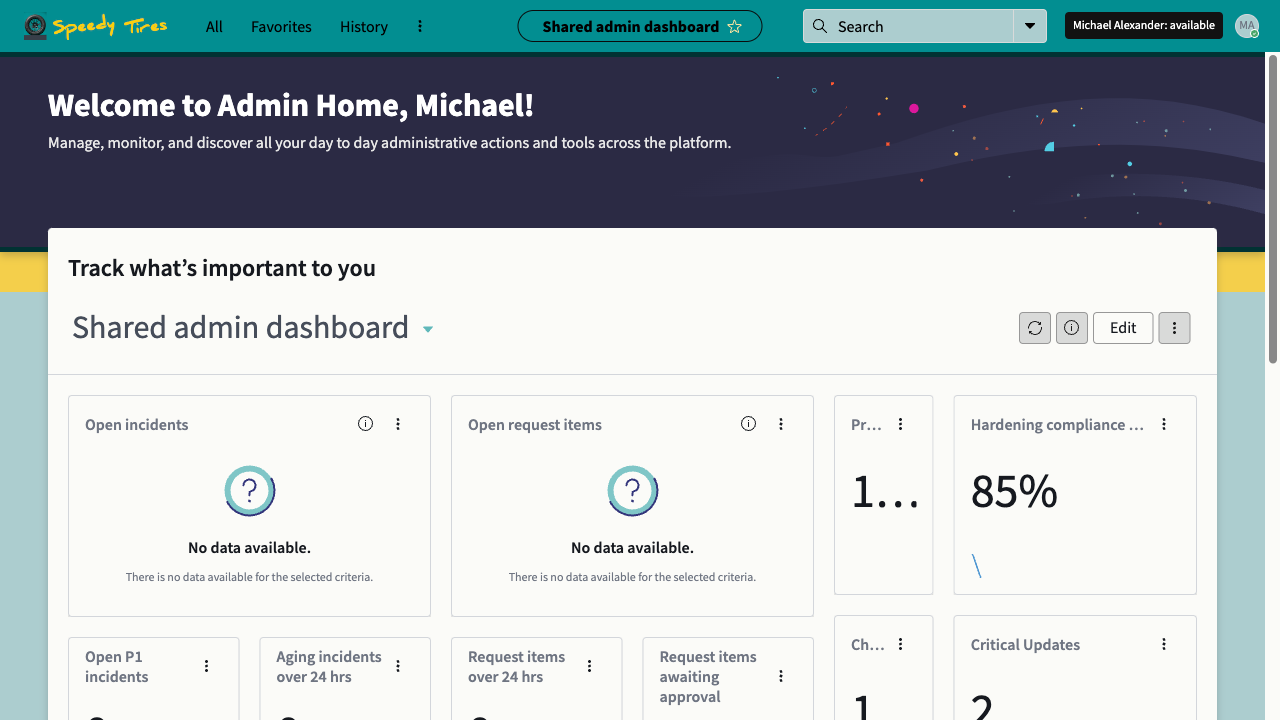

----------
Thinking: The menu is visible in the AXTree. I will try to click "Impersonate user" (bid '274') again. If this fails, I will try using the `press` action on the focused element to navigate the menu.
Action: click('274')


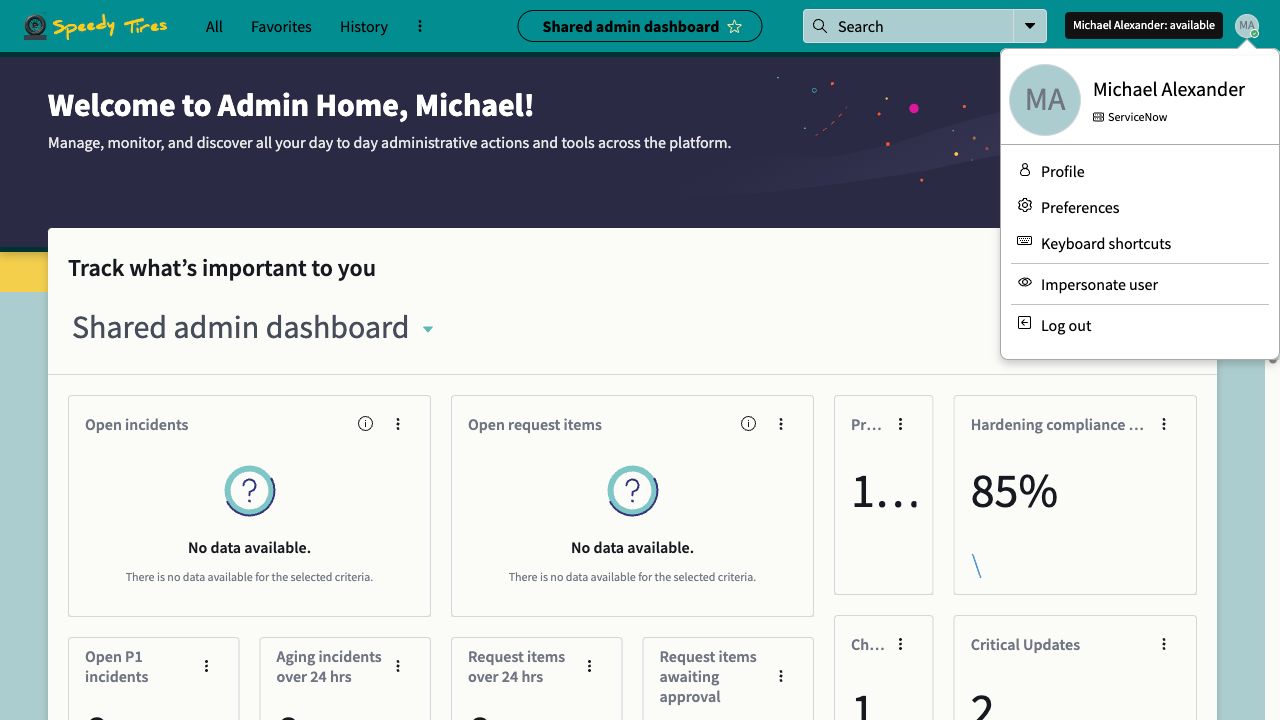

----------
Thinking: The previous attempts to click "Impersonate user" (bid '274') have repeatedly failed with a visibility error, despite the element appearing in the AXTree. This often happens in ServiceNow when the menu is in a transient state. I will try to use the `press` action with the 'Enter' key on the profile button (bid '179') or try to navigate using keyboard keys if the menu is open. Since '179' is focused, I'll try to press 'ArrowDown' to see if I can highlight the menu items.
Action: press('179', 'ArrowDown')


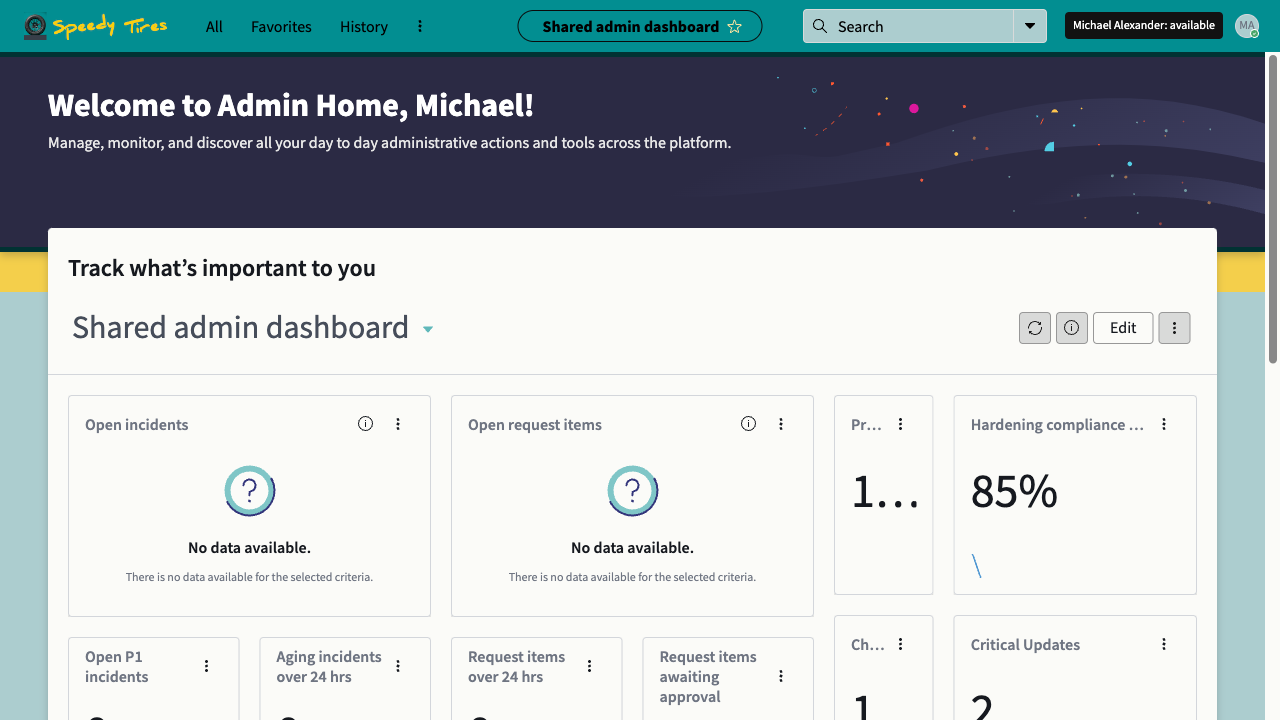

----------
Thinking: The previous action `press('179', 'ArrowDown')` was intended to navigate the user menu. Looking at the current AXTree, the profile button (bid '179') is still focused. I will try to click the "Impersonate user" button (bid '274') again, as it is visible in the AXTree. If it continues to fail, I will try a different approach like searching for the user directly if possible, but impersonation is the standard way. Let's try clicking '274' again.
Action: click('274')


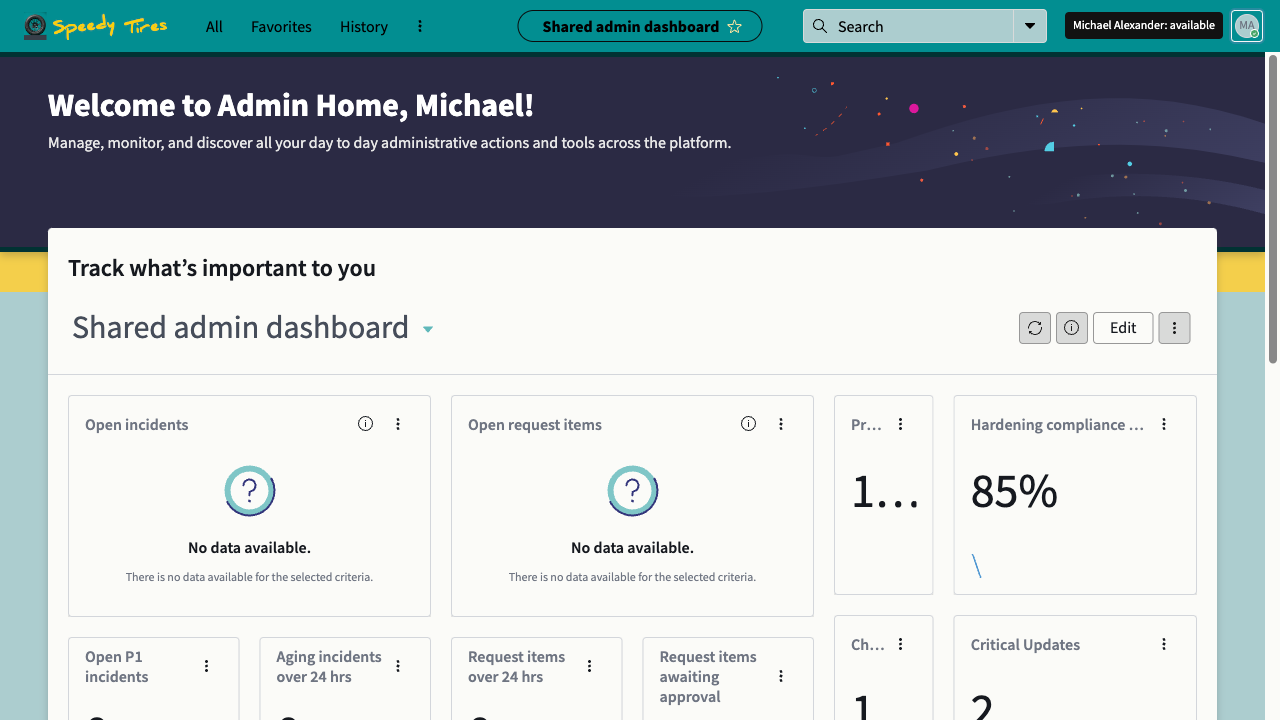

----------
Thinking: The previous attempts to click "Impersonate user" (bid '274') have failed repeatedly with a visibility error. I have tried clicking the profile button and using keyboard navigation. I will try to click the profile button (bid '179') again to ensure the menu is open, and then I will try to click the "Impersonate user" button (bid '274') one more time. If it fails, I'll consider if there's another way to trigger the impersonation dialog.
Action: click('179')


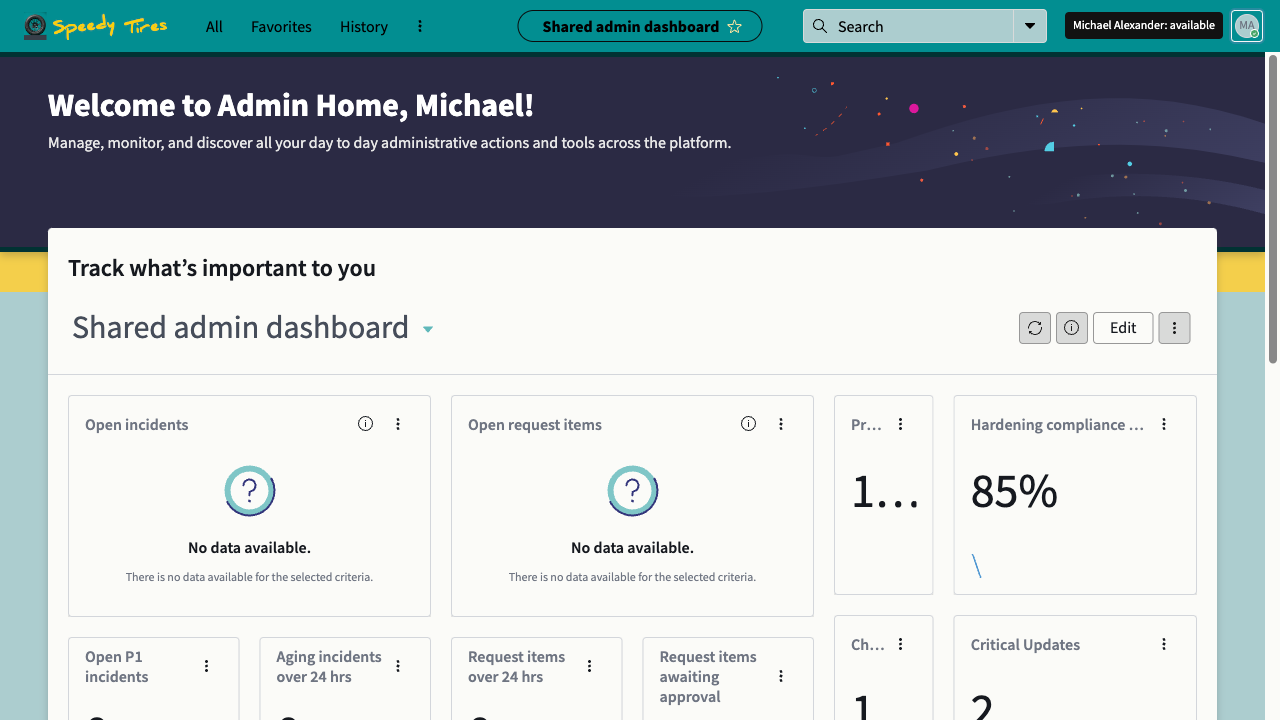

----------
Thinking: The user menu is open and "Impersonate user" (bid '274') is visible. I will try clicking it again.
Action: click('274')


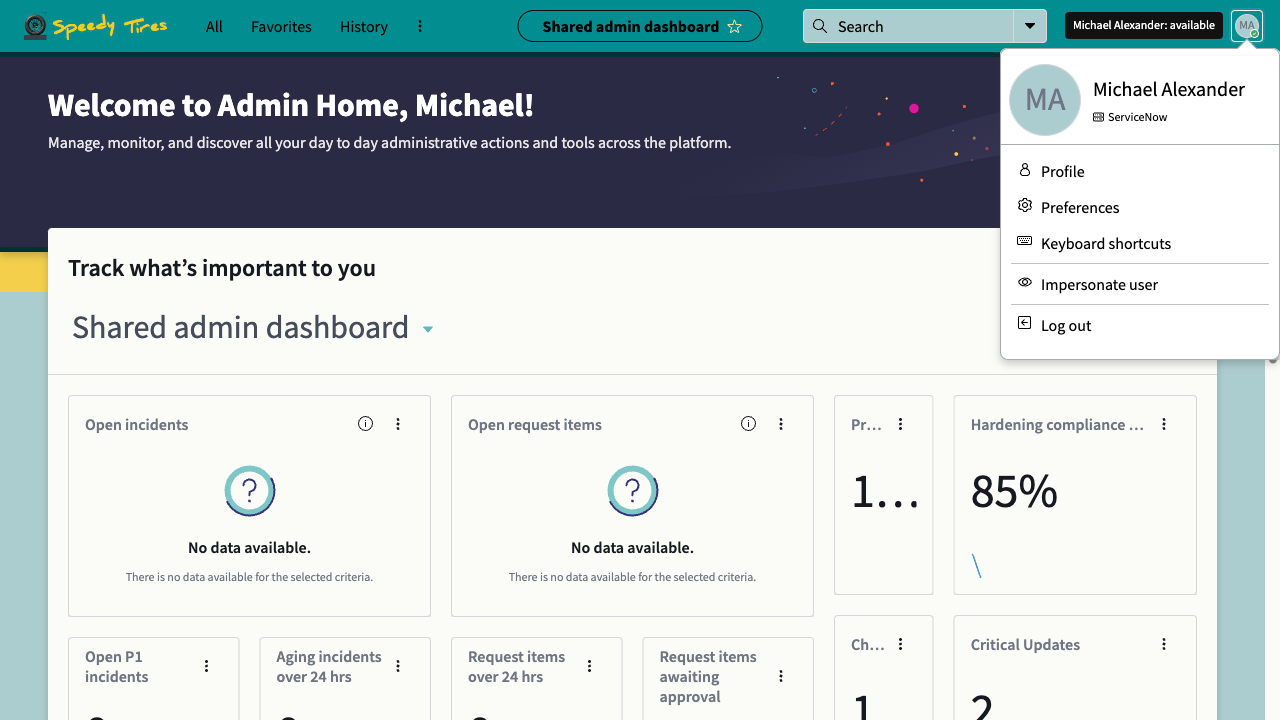

----------
Thinking: The previous attempt to click "Impersonate user" (bid '274') failed again with a visibility error. I have tried multiple times to click the profile button and then the menu item. I will try to use the `press` action with 'Enter' on the profile button '179' while it is focused, or I'll try to click the profile button '179' again and then wait. Since '179' is currently focused, I will try pressing 'Enter' to see if it triggers the menu in a way that makes the children interactable.
Action: press('179', 'Enter')


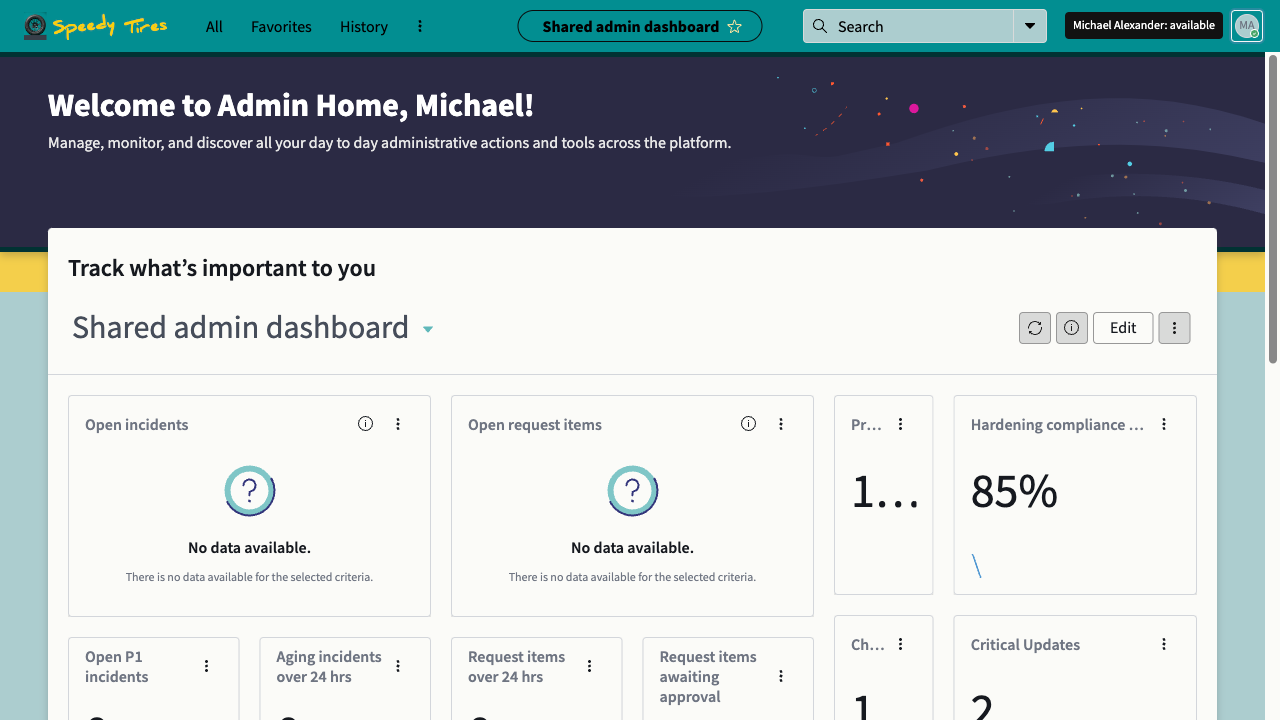

----------


KeyError: 'think'

In [13]:
# lazy loader for all the information of on experiment (1 agent on 1 task)
result = ExpResult(filtered_result_df.iloc[1].exp_dir)
episode = result.steps_info

for step_number in range(len(episode)):
    print(f"Thinking: {episode[step_number].agent_info['think']}")
    print(f"Action: {episode[step_number].action}")
    display(result.get_screenshot(step_number))
    print("-"*10)

action: click('a941')
reward: 0
AXTree: RootWebArea 'Assessment Overview | ServiceNow', focused
	[46] generic, live='assertive', atomic, relevant='additions text'
	[47] generic, live='polite', atomic, relevant='additions text'
	[52] generic, live='polite', atomic, relevant='all'
	[55] navigation 'Global skip links', visible
		[56] link 'Skip to main content', clickable
		[57] link 'Open accessibility preferences', clickable
	[235] region 'There are 0 announcements displayed', visible, live='polite', relevant='additions text'
	[58] gen
screenshot type: <class 'numpy.ndarray'>


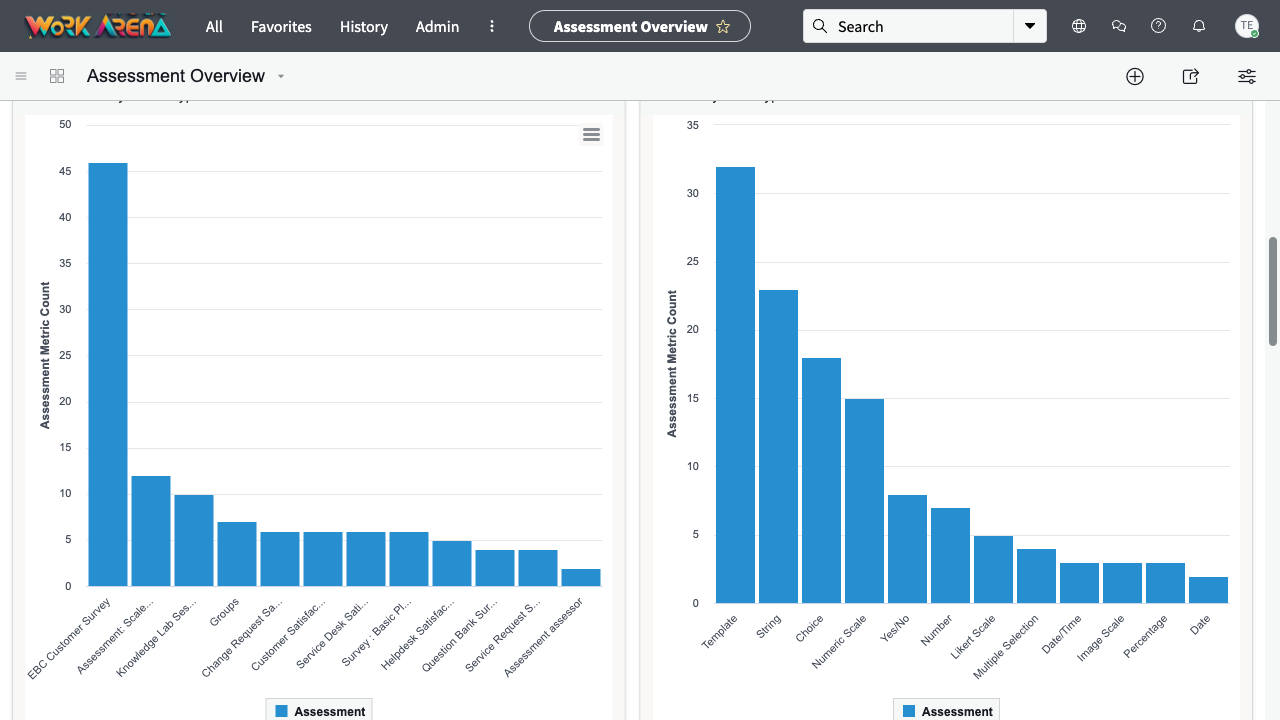

In [ ]:
# lazy loader for all the information of on experiment (1 agent on 1 task)
result = ExpResult(result_df.iloc[0].exp_dir)

episode = result.steps_info
print(f"action: {episode[1].action}")
print(f"reward: {episode[1].reward}")
print(f"AXTree: {episode[1].obs['axtree_txt'][:500]}")

# formatted as an array
print(f"screenshot type: {type(episode[1].obs['screenshot'])}")

# loading from png
display(result.get_screenshot(1))

# List Keys in the Observation dict

In [ ]:
print(f"Obs Keys:\n  {'\n  '.join(list(episode[1].obs.keys()))}")

Obs Keys:
  chat_messages
  goal
  goal_object
  open_pages_urls
  open_pages_titles
  active_page_index
  url
  dom_object
  axtree_object
  extra_element_properties
  focused_element_bid
  last_action
  last_action_error
  elapsed_time
  dom_txt
  axtree_txt
  pruned_html
  screenshot


# extra_elements_properties

In [9]:
extra_properties = json.dumps(episode[1].obs["extra_element_properties"], indent=2)
print(extra_properties)

{
  "0": {
    "visibility": 1.0,
    "bbox": [
      0.0,
      0.0,
      2560.0,
      1440.0
    ],
    "clickable": false,
    "set_of_marks": false
  },
  "1": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "2": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "3": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "4": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "5": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "6": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "7": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "8": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
 